# Imports

In [11]:
import pandas as pd
import numpy as np
import json
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the pre-trained Random Forest, Feature Names and data
model_dir = "../api/saved_models"
data_dir = "../data/training"
data_path = "../data/training/augmented_training_data.jsonl"


rf_model = joblib.load(f"{model_dir}/rf_model.pkl")
X = pd.read_csv(f"{data_dir}/training_features.csv")

print("Model and data loaded successfully.")

Model and data loaded successfully.


# Data Inspection

In [12]:
print("--- Inspecting Raw Qwen LLM Outputs ---\n")

# Read the first 5 records to see the exact formatting Qwen used
with open(data_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break

        record = json.loads(line)
        file_id = record.get("file_id", "Unknown ID")
        extracted_features = record.get("extracted_features", {})

        print(f"Candidate: {file_id}")
        # Pretty-print the dictionary with a 2-space indent
        print(json.dumps(extracted_features, indent=2))
        print("-" * 50)

--- Inspecting Raw Qwen LLM Outputs ---

Candidate: mismatch_23
{
  "technical_skills": [
    "MS Word",
    "MS Excel",
    "MS PowerPoint",
    "Windows 7",
    "Ubuntu 18.04"
  ],
  "years_of_experience": 11,
  "education": "B.Com",
  "projects_count": 0,
  "job_hopping": "High",
  "structural_adherence": 2,
  "adaptive_fluidity": 3,
  "interpersonal_influence": 3,
  "execution_velocity": 2,
  "psychological_resilience": 2
}
--------------------------------------------------
Candidate: match_41
{
  "technical_skills": [
    "Microsoft Word",
    "Microsoft PowerPoint",
    "Microsoft Excel",
    "Digital Marketing",
    "Influencer Marketing",
    "Digital PR"
  ],
  "years_of_experience": 11,
  "education": "MBA",
  "projects_count": 0,
  "job_hopping": "Medium",
  "structural_adherence": 4,
  "adaptive_fluidity": 3,
  "interpersonal_influence": 5,
  "execution_velocity": 4,
  "psychological_resilience": 3
}
--------------------------------------------------
Candidate: match_71
{
 

# Initialize TreeExplainer

In [13]:
explainer = shap.TreeExplainer(rf_model)

# Select a specific candidate to analyze
candidate_idx = 0
candidate_features = X.iloc[[candidate_idx]]

# Get Objective Score directly
objective_score = rf_model.predict(candidate_features)[0]

# Calculate SHAP values for this specific candidate
shap_values = explainer.shap_values(candidate_features)

base_value = explainer.expected_value # average score of dataset
if isinstance(base_value, np.ndarray):
    base_value = base_value[0]

print(f"Objective System Score: {objective_score:.2f} / 100")
print(f"Model Base Value (Average Score): {base_value:.2f} / 100")

Objective System Score: 78.68 / 100
Model Base Value (Average Score): 86.23 / 100


# Define Subjective UI Weights

In [14]:
# Mapping UI slider states to multipliers
weight_mapping = {
    "Ignore": 0.0,
    "Low": 0.5,
    "Normal": 1.0,
    "High": 1.5,
    "Critical": 2.0
}

recruiter_sliders = {
    "years_of_experience": "Normal",
    "structural_adherence": "Ignore",
    "adaptive_fluidity": "Critical",
    "interpersonal_influence": "Normal",
    "execution_velocity": "Critical",
    "psychological_resilience": "High",
    "edu_Bachelors": "Normal",
    "edu_Masters": "Normal",
    "edu_PhD": "Normal",
    "edu_None": "Normal"
}

# Apply multipliers to calculate the user score
adjusted_shap_values = []
subjective_log_odds = base_value

for i, feature_name in enumerate(X.columns):
    original_shap = shap_values[0][i]
    slider_state = recruiter_sliders.get(feature_name, "Normal")
    multiplier = weight_mapping[slider_state]

    # Calculate weighted SHAP
    weighted_shap = original_shap * multiplier
    adjusted_shap_values.append(weighted_shap)

    subjective_log_odds += weighted_shap

# Convert the adjusted log-odds back to a probability score
subjective_score = 1 / (1 + np.exp(-subjective_log_odds))

print(f"Subjective User Score (Weighted): {subjective_score:.4f}")

Subjective User Score (Weighted): 1.0000


# Evaluate Risk Flags

In [15]:
RISK_THRESHOLD = 0.20

is_risk_flagged = False
if abs(subjective_score - objective_score) >= RISK_THRESHOLD:
    is_risk_flagged = True
    print("⚠️ POTENTIAL RISK FLAG TRIGGERED!")
else:
    print("✅ Candidate aligns safely with model baseline.")

# Extract Top Contributing Features for the LLM Prompt
feature_impacts = pd.DataFrame({
    'Feature': X.columns,
    'Value': candidate_features.iloc[0].values,
    'Original_SHAP': shap_values[0],
    'Adjusted_SHAP': adjusted_shap_values
})

# Sort by absolute impact to find the most driving factors
feature_impacts['Abs_Impact'] = feature_impacts['Original_SHAP'].abs()
top_drivers = feature_impacts.sort_values(by='Abs_Impact', ascending=False).head(5)

print("\nTop 5 Drivers for LLM Question Generation:")
print(top_drivers[['Feature', 'Value', 'Original_SHAP']])

⚠️ POTENTIAL RISK FLAG TRIGGERED!

Top 5 Drivers for LLM Question Generation:
                    Feature  Value  Original_SHAP
2      structural_adherence    2.0      -6.079149
4   interpersonal_influence    3.0      -3.792690
3         adaptive_fluidity    4.0       2.657832
6  psychological_resilience    3.0      -2.002580
1           education_level    3.0       1.284561


# Plotting

--- Objective System Evaluation ---


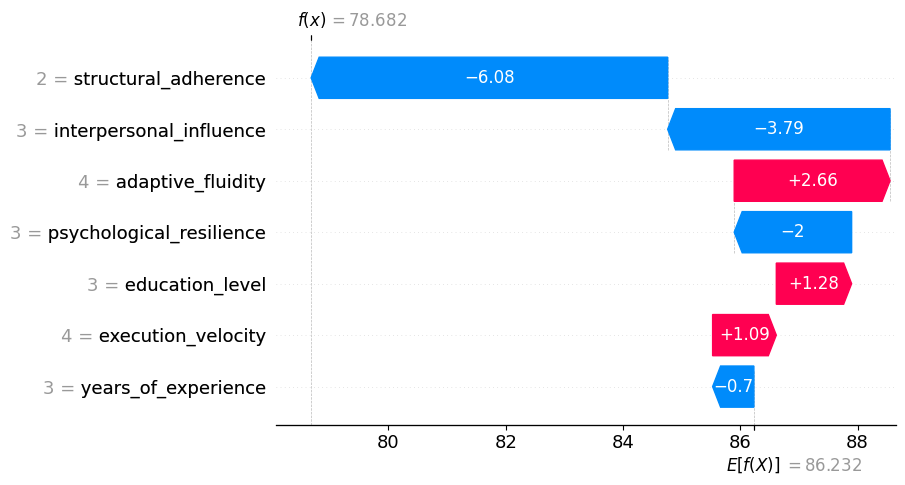

--- Subjective Recruiter Evaluation (Weighted) ---


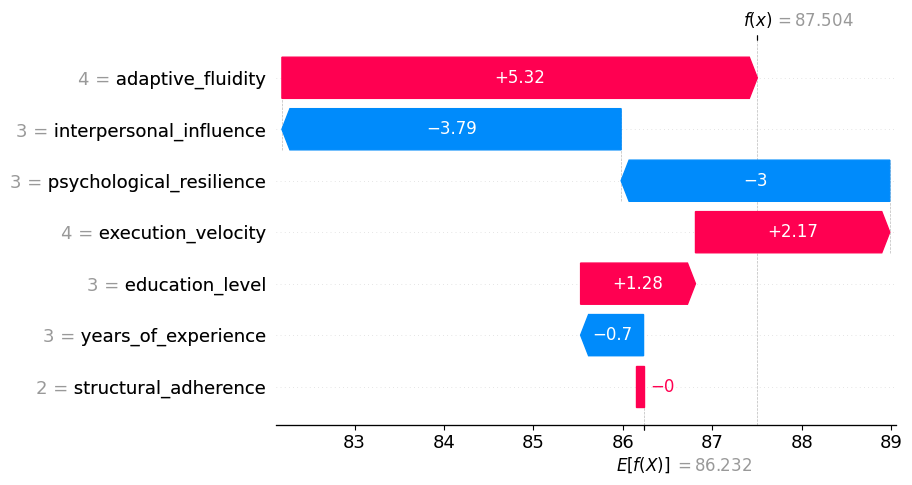

In [16]:
explanation_objective = shap.Explanation(
    values=shap_values[0],
    base_values=base_value,
    data=candidate_features.iloc[0].values,
    feature_names=X.columns
)

explanation_subjective = shap.Explanation(
    values=np.array(adjusted_shap_values),
    base_values=base_value,
    data=candidate_features.iloc[0].values,
    feature_names=X.columns
)

plt.figure(figsize=(10, 5))
print("--- Objective System Evaluation ---")
shap.plots.waterfall(explanation_objective, max_display=10)

print("--- Subjective Recruiter Evaluation (Weighted) ---")
shap.plots.waterfall(explanation_subjective, max_display=10)